# IMPORT LIBRARIES

In [2]:
import pyodbc
import pycountry
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy.exc import SAWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=SAWarning)

# CONNECT WITH SQL SERVER

In [3]:
def connect_to_sql_server():
    try:
        conn = pyodbc.connect(
            'DRIVER={SQL Server};'
            'SERVER=.\\SQLEXPRESS;'  
            'DATABASE=Northwind;'  
            'Trusted_Connection=yes;' 
        )
        return conn
    except pyodbc.Error as e:
        print(f"Can't Connect !: {e}")
        return None

# Read Data 

In [4]:
def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"Error loading data: {e}")
            return None
    return None

# Close Connection

In [5]:
def close_connection(conn):
    if conn:
        conn.close()
        print("Connection closed successfuly")

# Check if the data connected successfully by any select statment

In [6]:
conn = connect_to_sql_server()

product_query = """
    SELECT ProductName, SUM(Quantity) AS TotalQuantity
    FROM Products p
    JOIN [Order Details] od ON p.ProductID = od.ProductID
    GROUP BY ProductName
    ORDER BY TotalQuantity DESC;
    """ 
df = read_data_from_sql(conn, product_query)

if df is not None:
    print(df) 
else:
    print("No Data exists.")

close_connection(conn)

                  ProductName  TotalQuantity
0           Camembert Pierrot           1577
1        Raclette Courdavault           1496
2           Gorgonzola Telino           1397
3      Gnocchi di nonna Alice           1263
4                     Pavlova           1158
..                        ...            ...
72  Laughing Lumberjack Lager            184
73                  Chocolade            138
74                 Gravad lax            125
75               Genen Shouyu            122
76            Mishi Kobe Niku             95

[77 rows x 2 columns]
Connection closed successfuly


# Sales Per Time

In [7]:
conn = connect_to_sql_server()
salestime_query = """
SELECT 
    YEAR(OrderDate) AS OrderYear,
    MONTH(OrderDate) AS OrderMonth,
    SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM Orders o
JOIN [Order Details] od ON o.OrderID = od.OrderID
GROUP BY YEAR(OrderDate), MONTH(OrderDate)
ORDER BY OrderYear, OrderMonth
"""
df = read_data_from_sql(conn, salestime_query)
if df is not None:
    print(df) 
else:
    print("No Data exists.")

    OrderYear  OrderMonth     TotalSales
0        1996           7   27861.894974
1        1996           8   25485.274970
2        1996           9   26381.399973
3        1996          10   37515.725197
4        1996          11   45600.044844
5        1996          12   45239.629696
6        1997           1   61258.070463
7        1997           2   38483.634981
8        1997           3   38547.219996
9        1997           4   53032.952518
10       1997           5   53781.290039
11       1997           6   36362.802532
12       1997           7   51020.857527
13       1997           8   47287.670330
14       1997           9   55629.242485
15       1997          10   66749.225880
16       1997          11   43533.809015
17       1997          12   71398.428598
18       1998           1   94222.110553
19       1998           2   99415.287338
20       1998           3  104854.155029
21       1998           4  123798.682137
22       1998           5   18333.630543


# Visualization

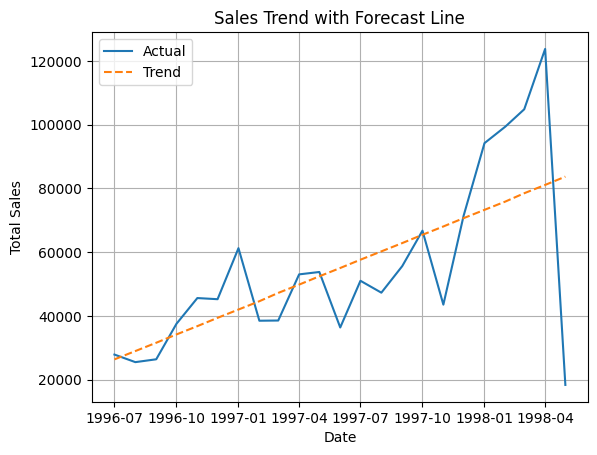

In [8]:
df['Date'] = pd.to_datetime(
    df['OrderYear'].astype(str) + '-' +
    df['OrderMonth'].astype(str) + '-01'
)

df = df.sort_values('Date')

df['TimeIndex'] = np.arange(len(df))

coeff = np.polyfit(df['TimeIndex'], df['TotalSales'], 1)
trend = np.poly1d(coeff)

df['TrendLine'] = trend(df['TimeIndex'])

plt.plot(df['Date'], df['TotalSales'], label='Actual')
plt.plot(df['Date'], df['TrendLine'], linestyle='--', label='Trend')

plt.title("Sales Trend with Forecast Line")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

# Top 10 Product Selling

In [9]:
top10_query = """ 
    SELECT TOP 10
    p.ProductName,
    SUM(od.Quantity) AS TotalQuantitySold,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM [Order Details] od
JOIN Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalRevenue DESC;
"""
df = read_data_from_sql(conn, top10_query)
if df is not None:
    print(df) 
else:
    print("No Data exists.")

               ProductName  TotalQuantitySold  TotalRevenue
0            Côte de Blaye                623      149984.2
1  Thüringer Rostbratwurst                746       87736.4
2     Raclette Courdavault               1496       76296.0
3        Camembert Pierrot               1577       50286.0
4           Tarte au sucre               1083       49827.9
5   Gnocchi di nonna Alice               1263       45121.2
6    Manjimup Dried Apples                886       44742.6
7             Alice Mutton                978       35482.2
8         Carnarvon Tigers                539       31987.5
9        Rössle Sauerkraut                640       26865.6


# Visualization

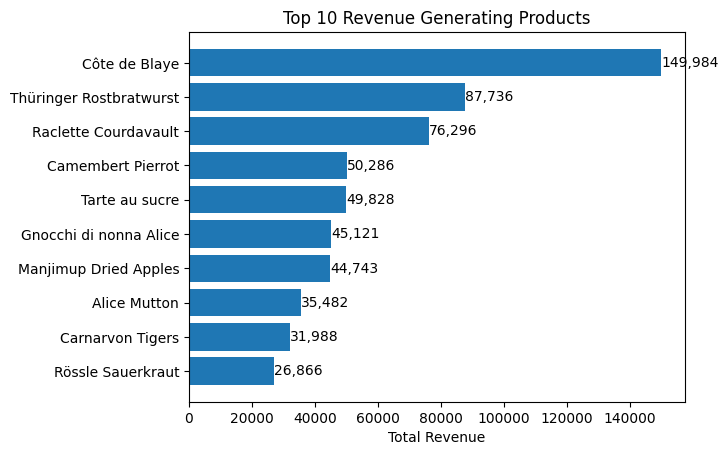

In [10]:
bars = plt.barh(df['ProductName'], df['TotalRevenue'])

plt.xlabel("Total Revenue")
plt.title("Top 10 Revenue Generating Products")

plt.gca().invert_yaxis()

for i, v in enumerate(df['TotalRevenue']):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.show()

# Sales Per Employee

In [11]:
salemp_query = """ 
    SELECT 
    e.FirstName + ' ' + e.LastName AS EmployeeName,
    COUNT(DISTINCT o.OrderID) AS TotalOrders,
    SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM Employees e
JOIN Orders o ON e.EmployeeID = o.EmployeeID
JOIN [Order Details] od ON o.OrderID = od.OrderID
GROUP BY e.FirstName, e.LastName
ORDER BY TotalSales DESC;
"""
df = read_data_from_sql(conn, salemp_query)
if df is not None:
    print(df) 
else:
    print("No Data exists.")

       EmployeeName  TotalOrders     TotalSales
0  Margaret Peacock          156  232890.845947
1   Janet Leverling          127  202812.842793
2     Nancy Davolio          123  192107.604321
3     Andrew Fuller           96  166537.754978
4    Laura Callahan          104  126862.277704
5       Robert King           72  124568.235382
6    Anne Dodsworth           43   77308.066710
7    Michael Suyama           67   73913.129244
8   Steven Buchanan           42   68792.282539


# Visualization

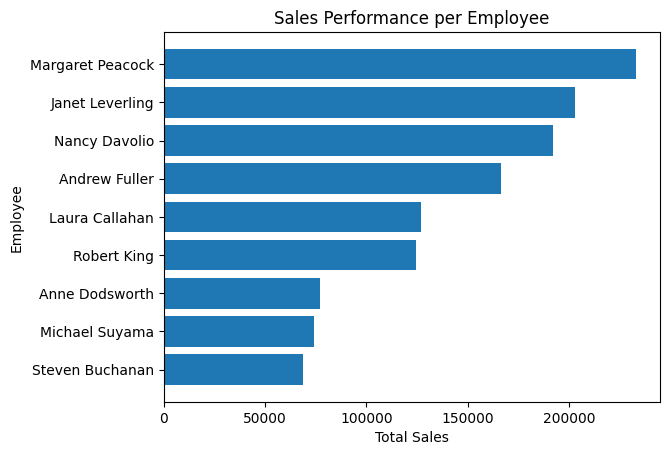

In [12]:
bars = plt.barh(df['EmployeeName'], df['TotalSales'])

plt.xlabel("Total Sales")
plt.ylabel("Employee")
plt.title("Sales Performance per Employee")

plt.gca().invert_yaxis()
plt.show()

# Sales by Country

In [13]:
counsal_query = """
SELECT 
    o.ShipCountry,
    SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM Orders o
JOIN [Order Details] od ON o.OrderID = od.OrderID
GROUP BY o.ShipCountry
ORDER BY TotalSales DESC;
"""

df_country = pd.read_sql(counsal_query, conn)

In [14]:
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

# Visualization

In [17]:
df_country["ISO3"] = df_country["ShipCountry"].apply(get_iso3)
df_country = df_country.dropna(subset=["ISO3"])
fig = px.choropleth(
    df_country,
    locations="ISO3",
    color="TotalSales",
    hover_name="ShipCountry",
    hover_data={"ISO3":False,"TotalSales":":,.2f"},
    color_continuous_scale="Viridis",
    title="<b>Total Sales by Country</b>"
)

fig.update_traces(
    hovertemplate="<b>Country:</b> %{hovertext}<br><b>Sales:</b> $%{z:,.0f}<extra></extra>",
    hoverlabel=dict(
        bgcolor="white",      
        font_size=14,    
        font_family="Arial",  
        bordercolor="black"  
    )
)
fig.update_layout(
    title_font_size=22,
    title_x=0.5,
    width=800,     
    height=400, 
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="Black",
        projection_type="natural earth",
        landcolor='#f3f3f3',
        showland=True
    ),
    coloraxis_colorbar=dict(
        title="Total Sales",
        tickprefix="$"
    ),
    template="plotly_white" ,
    margin={"r":0,"t":80,"l":0,"b":0}
)

# Profit Analysis

In [18]:
query = """ SELECT
    SUM(od.UnitPrice * od.Quantity) AS GrossRevenue,
    SUM(od.UnitPrice * od.Quantity * od.Discount) AS TotalDiscount,
    SUM((od.UnitPrice * 0.7) * od.Quantity) AS EstimatedCost
FROM [Order Details] od; """
df = pd.read_sql(query, conn)

gross = df['GrossRevenue'][0]
discount = df['TotalDiscount'][0]
cost = df['EstimatedCost'][0]

net_revenue = gross - discount
profit = net_revenue - cost

# Visalization

In [19]:
fig = go.Figure(go.Waterfall(
    name="Profit Breakdown",
    orientation="v",
    measure=["absolute", "relative", "relative", "relative", "total"],
    x=["Gross Revenue", "Discounts", "Cost", "Net Effect", "Profit"],
    y=[gross, -discount, -cost, 0, profit],
))

fig.update_layout(
    title="Profit Waterfall Analysis",
    showlegend=False
)

fig.show()